# Exercícios do Capítulo 1 — Processamento Digital de Sinais

Capítulo 1 do livro **Processamento Digital de Sinais** de Paulo S. R. Diniz.

## Sobre o Capítulo 1

O Capítulo 1 apresenta os conceitos básicos do Processamento Digital de Sinais (DSP), incluindo:
- Definição de sinais e sistemas
- Diferenças entre sinais contínuos e discretos
- Convolução discreta
- Teorema da Amostragem

## Objetivos Principais:
- Utilizar pacotes do Python para representar e manipular sinais discretos.
-  Implementação de uma função que receba dois sinais discretos retorne o resultado da convolução discreta entre eles.
-  Análise da complexidade computacional da implementação.
- Testar ferramentas de aceleração de código, tais como Numba e CuPy.

## Vamos utilizar bibliotecas Python para representação e manipulação de sinais discretos com implementações de Convolução

- NumPy : https://numpy.org/doc/stable/user/absolute_beginners.html
- Scipy.signal: https://docs.scipy.org/doc/scipy/reference/signal.html#convolution
- Matplotlib.pyplot: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html

Representando o Impulso Unitário

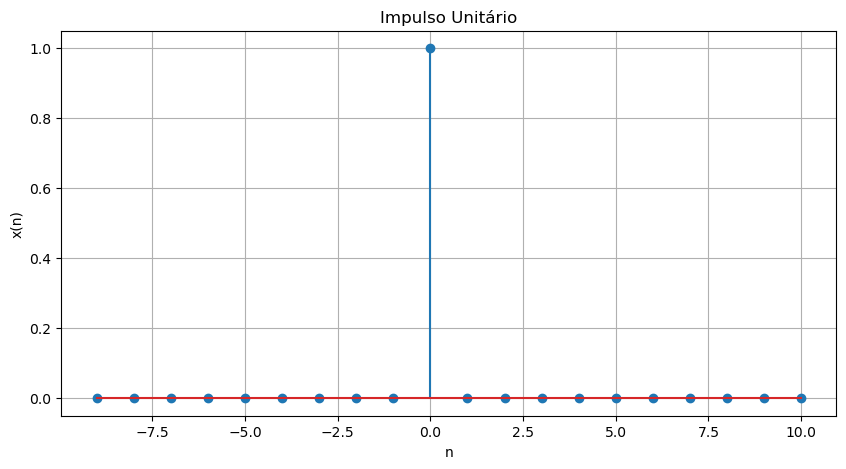

In [1]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

# Implementando o impulso unitário

n= np.arange(-9,11) #criando o vetor n de -9 a 10 em polegadas
impulse= np.where(n==0, 1, 0) #criando o impulso unitário
#np.where(condição, valor_se_verdadeiro, valor_se_falso)

# Plotando o impulso unitário
plt.figure(figsize=(10, 5))#Criando a figura e definindo o tamanho


plt.stem(n,impulse)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Impulso Unitário')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

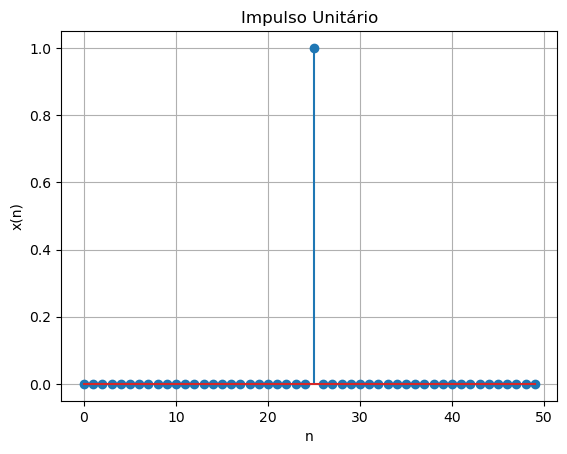

In [2]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

# Implementando uma função impulso unitário deslocado em k


def impulse(n_inicio, n_fim, k=0, amplitude=1.0):
    """
    Gera um sinal de impulso discreto, possivelmente deslocado.
    O deslocamento (n-k) é controlado pelo parâmetro 'posicao'.
    """
    n = np.linspace(n_inicio, n_fim, 50) #cria o vetor n com 200 pontos entre n_inicio e n_fim

    rough = np.argmin(np.abs(n-k)) #encontra o índice mais próximo de posicao 
    #np.argmin= encontra o índice do menor valor 
    #np.abs= retorna o valor absoluto


    sinal = np.zeros_like(n)# Cria um vetor de zeros com o mesmo formato de n

    sinal[rough] = amplitude #define o valor do impulso na posição aproximada 
    return sinal


delta = impulse(-3, 3, 0, 1.0) #chama a função para gerar o impulso unitário deslocado em k=0 com amplitude 1.0


# Plotando o impulso unitário
plt.figure()#Criando a figura e definindo o tamanho

plt.stem(delta)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Impulso Unitário')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

<span style="font-size:24px">
   Representando o Degrau Unitário
</span>


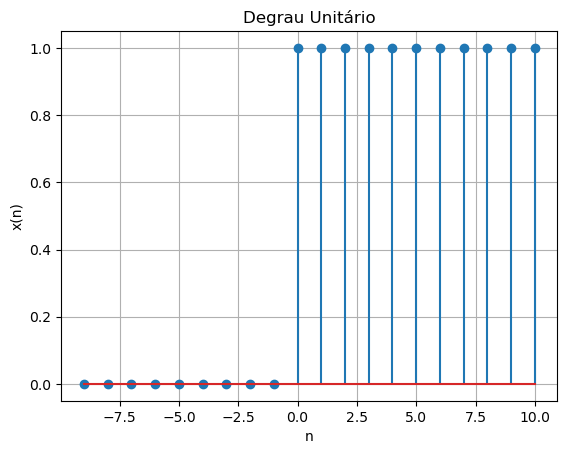

In [3]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal   

# Implementando o a função Degrau 

n= np.arange(-9,11) #criando o vetor n de -9 a 10
degrau= np.where(n>=0, 1, 0) #criando o impulso unitário
#np.where(condição, valor_se_verdadeiro, valor_se_falso)

# Plotando o Degrau Unitário
plt.figure()#Criando a figura e definindo o tamanho


plt.stem(n,degrau)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Degrau Unitário')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico


<span style="font-size:24px">
    Representando Sinais Senoidais
</span>

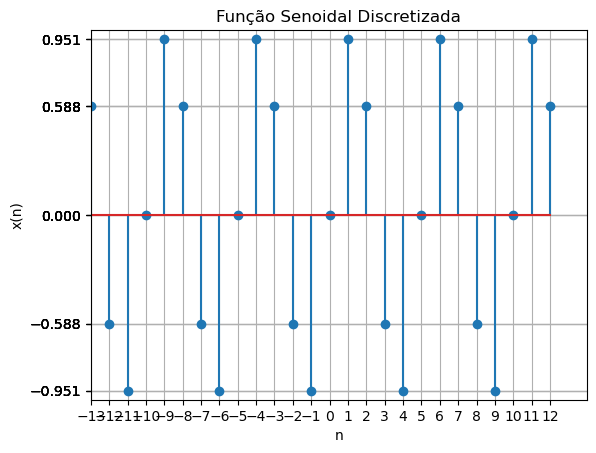

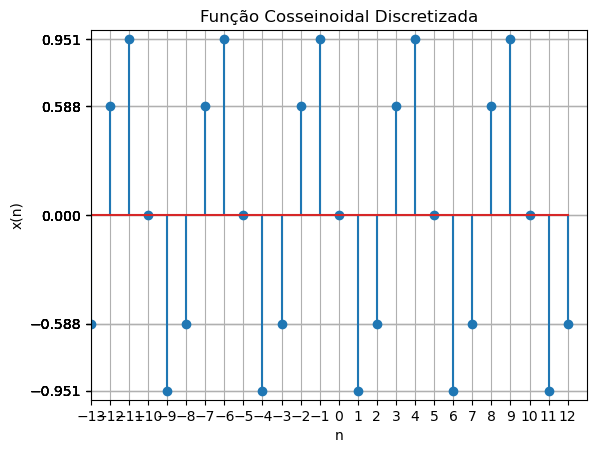

In [4]:
#Implementação das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal   

# Implementando Sinais Senoidais
N= 13 #numero de amostras
n= np.arange(-N,N) #criando o vetor n de 1000 amostras
A= 1 #amplitude do sinal
t= 5 #periodo do sinal
f= 1/t #frequência do sinal

phi= 0 #fase do sinal
senoide= A * np.sin((2 * np.pi * f * n)  + phi) #criando o sinal senoidal
cossenoide= A*np.cos((2*np.pi*f*n) + (phi+ np.pi/2)) #criando o sinal cossenoidal
# Plotando o Sinais Senoidais
plt.figure()#Criando a figura e definindo o tamanho


plt.stem(n,senoide)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Função Senoidal Discretizada')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y
plt.xticks(n)   # Define os valores do eixo x para mostrar todos os pontos
plt.yticks(senoide)  # Define os valores do eixo y para mostrar todos os pontos
plt.xlim(-N, N+1)  # Define o limite do eixo x para mostrar todos os pontos
plt.ylim(-A, A)  # Define o limite do eixo y para mostrar todos   

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

# Plotando o Sinais Cossenoidais
plt.figure()#Criando a figura e definindo o tamanho

plt.stem(n,cossenoide)#desenha o grafico sem hastes

#nomear eixos e título
plt.title('Função Cosseinoidal Discretizada')#título do gráfico
plt.xlabel('n')#rótulo do eixo x
plt.ylabel('x(n)')#rótulo do eixo y
plt.xticks(n)   # Define os valores do eixo x para mostrar todos os pontos
plt.yticks(cossenoide)  # Define os valores do eixo y para mostrar todos os pontos
plt.xlim(-N, N)  # Define o limite do eixo x para mostrar todos os pontos
plt.ylim(-A, A)  # Define o limite do eixo y para mostrar todos   

plt.grid(True)#adiciona uma grade ao gráfico
plt.show()#mostra o gráfico

<span style="font-size:24px">
    Realizar a Convolução em python, tentar refazer a função np.convolve da biblioteca NumPy
</span>


A convolução em tempo discreto é uma operação essencial para analisar sistemas lineares e invariantes no tempo (LTI). Ela permite determinar a saída de um sistema para qualquer entrada, conhecendo apenas a resposta ao impulso do sistema.

A convolução de dois sinais discretos $x[n]$ e $h[n]$ é definida por:

$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n - k]
$$

Onde:
- $x[n]$: sinal de entrada
- $h[n]$: resposta ao impulso do sistema
- $y[n]$: saída do sistema

## Implementação com Vetores Finitos em Python

Como lidamos com vetores de tamanho finito em Python, a fórmula costuma ser reescrita como:

$$
y[n] \;=\; \sum_{k=0}^{M-1} x[k]\;\cdot\;h[n - k]
$$


## Dimensões dos Vetores

- \(x\) tem tamanho \(M\)  
- \(h\) tem tamanho \(N\)  
- \(y\) terá tamanho \(M + N - 1\)  


Esse bloco de código mostra como implementar a convolução discreta em Python, aplicar a operação a sinais de exemplo e visualizar os resultados, incluindo o eixo de tempo correto para cada gráfico.

1° Convolução temos: 

Fórmula Geral da Convolução Discreta
A convolução discreta de dois sinais ( x(n) ) e ( h(n) ) é definida por:

$$ y(n) = (x * h)(n) = \sum_{k=-\infty}^{\infty} x(k) \cdot h(n - k) $$

No caso de vetores finitos de tamanho ( M ) e ( N ):

$$ y[n] = \sum_{k=0}^{M-1} x[k] \cdot h[n - k] $$

Convolução de ( x(n) ) com o Impulso Unitário ( \delta(n) )
Quando ( h(n) = \delta(n) ), temos:

$$ y(n) = \sum_{k=-\infty}^{\infty} x(k) \cdot \delta(n - k) $$

Pela propriedade do impulso unitário:

$$ y(n) = x(n) $$

Ou seja, a saída da convolução de qualquer sinal com o impulso unitário é o próprio sinal.


2° Convolução temos:

$$ y(n) = (x * h)(n) = \sum_{k=-\infty}^{\infty} x(k) \cdot h(n - k) $$

Portanto, a convolução fica:

$$ y(n) = \sum_{k=-\infty}^{\infty} \sin(k) \cdot e^{-(n-k)} $$

Como trabalhamos com vetores finitos de tamanho ( N ), a soma é limitada ao intervalo das amostras:

$$ y[n] = \sum_{k=0}^{N-1} x[k] \cdot h[n - k] $$

Ou, substituindo as funções:

$$ y[n] = \sum_{k=0}^{N-1} \sin(n_k) \cdot \exp(-(n_n - n_k)) $$

Onde ( n_k ) e ( n_n ) são os valores do vetor de amostras.

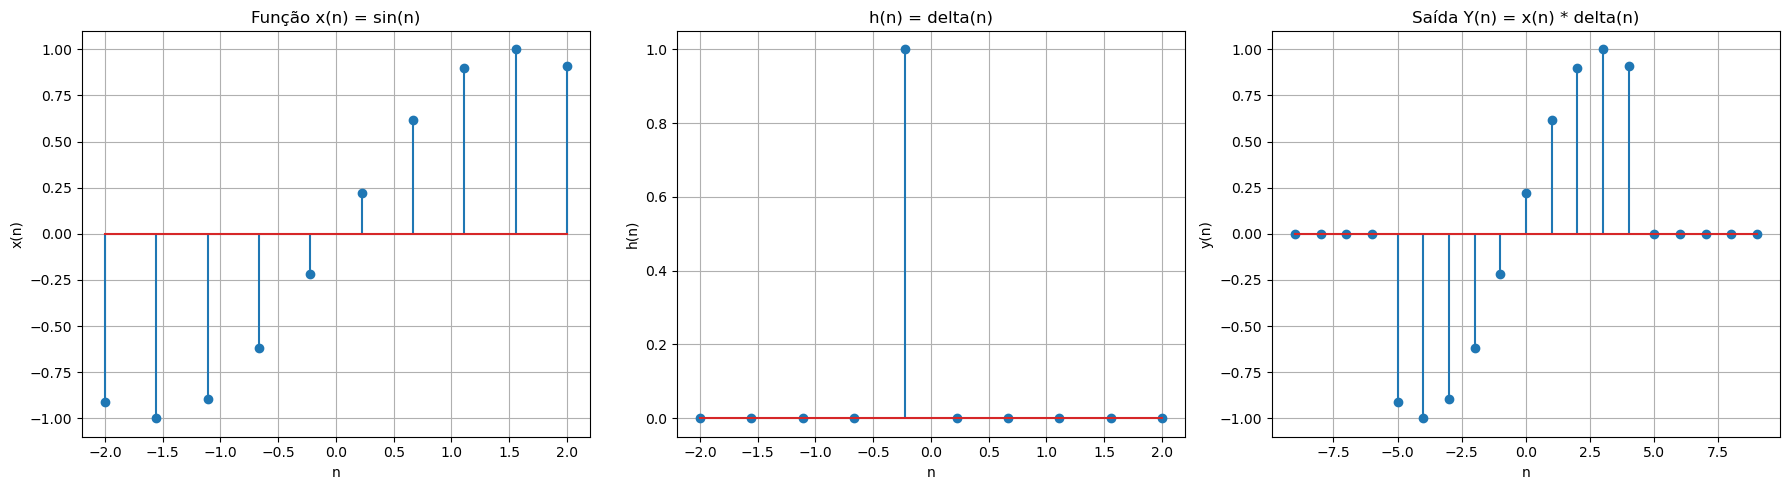

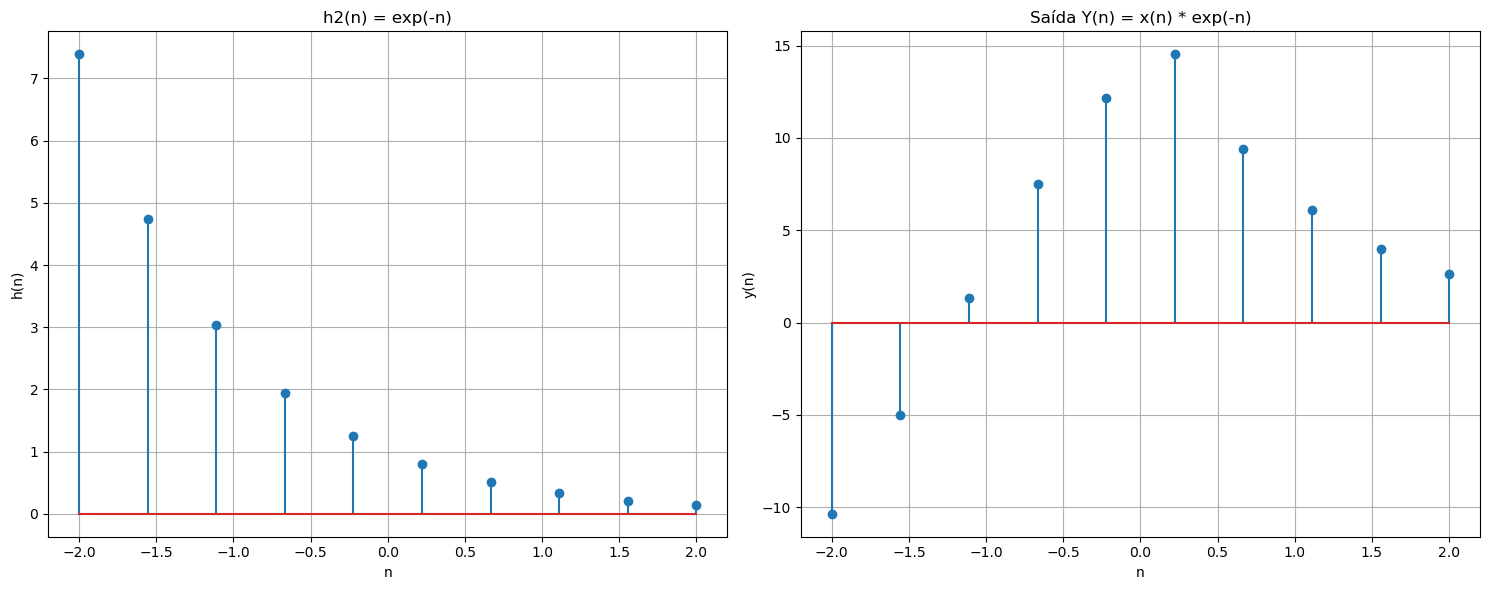

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal   



#Neste exemplo vamos implementar apenas o mode Full da convolução, que é o mais comum em aplicações de sinais discretos.

def convolucao(x, h , mode="full"):
    """
    Realiza a convolução entre dois sinais discretos x e h.
    O parâmetro 'mode' controla o tipo de convolução:
    - 'full': Convolução completa
    - 'valid': Convolução válida
    - 'same': Convolução com o mesmo tamanho do sinal de entrada x
    """
    #definir o tamanho dos sinais e onde havera convolução
    M = len(x)  # Tamanho do sinal x
    N = len(h)  # Tamanho do sinal h
    y= np.zeros(M + N - 1)  # Cria um vetor de zeros para armazenar o resultado da convolução com o tamanho (M + N - 1)

    for n in range(M + N - 1):#Laço para percorrer o tamanho (M + N - 1)
        for k in range(M): #dentro de outro laço para percorrer o tamanho de y(vetor de zeros da saida)
            if 0 <= n - k < N: # condição para verificar se o índice n-k está dentro dos limites do vetor y
                y[n] += x[k] * h[n - k]  # Realiza a convolução
    if mode == "full":  # Se o modo for 'full', retorna a convolução completa
        # A saída terá tamanho M + N - 1, que é o tamanho máximo da convolução
        return y

    elif mode == "same":  # Se o modo for 'same', retorna apenas a parte válida da convolução
        # Retorna a parte central da convolução, que tem o mesmo tamanho que o sinal de entrada x
        # A saida vai ter o mesmo numero de pontos que a entrada x(n)
        
        n_elements_cutted= (len(y) - len(x))  # Calcula o número de elementos a serem cortados
        centralized_idx = n_elements_cutted // 2  # Calcula o índice central para cortar o inicio

        #a divisao inteira // é usada para garantir que o índice seja um número inteiro e caso for impar, o valor central será o mais próximo do meio

        y = y[centralized_idx:centralized_idx + len(x)]  # Corta a convolução para manter o tamanho do sinal de entrada x
        #corta o array [inicio:final+1] para manter o tamanho do sinal de entrada x
        return y
    elif mode == "valid":  # Se o modo for 'valid', retorna apenas a parte válida da convolução
        # Retorna a parte válida da convolução, que é a parte onde ambos os sinais se sobrepõem completamente
        start= N-1
        end= M
        y=y[start:end]  # Corta a convolução para manter apenas a parte válida
        return y
    else :
        raise ValueError("Modo inválido. Use 'full', 'same' ou 'valid'.")   
    
            


def impulse(n_inicio, n_fim, n_amostras, k=0, amplitude=1.0):
    """
    Gera um sinal de impulso discreto, possivelmente deslocado.
    O deslocamento (n-k) é controlado pelo parâmetro 'posicao'.
    """
    n = np.linspace(n_inicio, n_fim, n_amostras) #cria o vetor n com 200 pontos entre n_inicio e n_fim

    rough = np.argmin(np.abs(n-k)) #encontra o índice mais próximo de posicao 
    #np.argmin= encontra o índice do menor valor 
    #np.abs= retorna o valor absoluto


    sinal = np.zeros_like(n)# Cria um vetor de zeros com o mesmo formato de n

    sinal[rough] = amplitude #define o valor do impulso na posição aproximada 
    return sinal

#Gerando um x(n) em um espaço de tempo discreto

amostras = np.linspace(-2, 2, 10)  # criando o vetor de tempo de -2 a 2 com 10 amostras
x_n = np.sin(amostras)

# Plotando a função x(n)
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.stem(amostras, x_n)
plt.title('Função x(n) = sin(n)')
plt.xlabel('n')
plt.ylabel('x(n)')
plt.grid(True)

# Gerando o impulso h(n)
# O vetor de tempo do impulso (n_impulse) é o mesmo 'amostras'

n_impulse = amostras
delta = impulse(n_inicio=-2, n_fim=2, n_amostras=10, k=0, amplitude=1.0)

# Plotando a função h(n)

plt.subplot(1, 3, 2)
plt.stem(n_impulse, delta)
plt.title('h(n) = delta(n)')
plt.xlabel('n')
plt.ylabel('h(n)')
plt.grid(True)


conv1 = convolucao(x_n, delta, mode="full")

n_conv = np.arange(-(len(x_n)-1), len(delta))

# Plotando a função y1(n)

plt.subplot(1, 3, 3)
plt.stem(n_conv, conv1)
plt.title('Saída Y(n) = x(n) * delta(n)')
plt.xlabel('n')
plt.ylabel('y(n)')
plt.grid(True)

plt.tight_layout() # Ajusta os plots para não se sobreporem
plt.show() # Mostra a primeira figura


# Gerando a exponencial h2(n)
exp = np.exp(-amostras)  # np.where não é necessário aqui

# Plotando a função exponencial h2(n)
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.stem(amostras, exp)
plt.title('h2(n) = exp(-n)')
plt.xlabel('n')
plt.ylabel('h(n)')
plt.grid(True)

conv2 = convolucao(x_n, exp, mode="same")
# O eixo de tempo para o resultado 'full' é a "soma" dos eixos de entrada.

n_conv2 = amostras

# Plotando a função y2(n)
plt.subplot(1, 2, 2)
plt.stem(n_conv2, conv2)
plt.title('Saída Y(n) = x(n) * exp(-n)')
plt.xlabel('n')
plt.ylabel('y(n)')
plt.grid(True)

plt.tight_layout() # Ajusta os plots para não se sobreporem
plt.show() # Mostra a segunda figura


"""
## Teoria da Amostragem (Nyquist)

A **Teoria da Amostragem de Nyquist-Shannon** é o princípio fundamental que nos permite digitalizar um sinal do mundo real (analógico) sem perder suas informações essenciais.

### A Regra Principal

Para reconstruir perfeitamente um sinal contínuo, a **frequência de amostragem** ($f_{amostragem}$) deve ser, no mínimo, **duas vezes maior** que a **frequência máxima** ($f_{máxima}$) contida no sinal original.

A fórmula é:

$$f_{amostragem} > 2 \cdot f_{máxima}$$

### O Problema do "Aliasing"

Se a regra não for seguida (subamostragem), ocorre o **aliasing**: o sinal digitalizado mostra frequências "falsas" e mais baixas que não existem no sinal original.

**Analogia:** É o mesmo efeito que faz as rodas de um carro em um filme parecerem girar lentamente ou para trás. A câmera (que amostra a uma certa taxa de quadros) não é rápida o suficiente para capturar o movimento real.

### Retornando ao Sinal Original (Interpolação)

Se a regra de Nyquist for respeitada, é matematicamente possível reconstruir o sinal analógico original perfeitamente a partir de suas amostras.

Isso é feito através da **fórmula de interpolação de Whittaker-Shannon**, que utiliza uma soma infinita de funções `sinc` ponderadas e deslocadas. Cada amostra `x[n]` contribui para a reconstrução do sinal contínuo `x(t)`:

$$x(t) = \sum_{n=-\infty}^{\infty} x[n] \cdot \operatorname{sinc}\left(\frac{t - nT_s}{T_s}\right)$$

Onde:
* `x(t)` é o sinal contínuo reconstruído.
* `x[n]` são os valores das amostras digitais.
* `T_s` é o período de amostragem (1 / f_amostragem).
* A função `sinc(y)` é definida como `sin(πy) / (πy)`.

Essencialmente, cada impulso (amostra) é substituído por uma função `sinc`, e a soma de todas essas funções `sinc` recria a forma de onda original.
"""


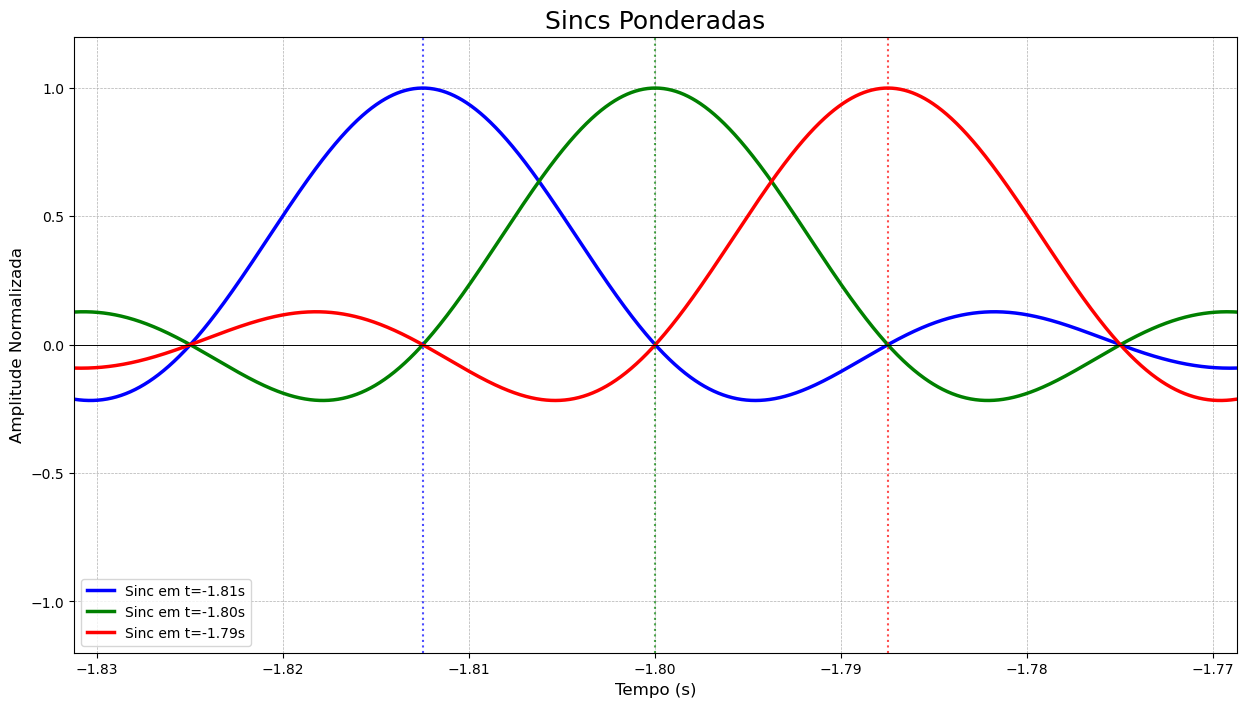

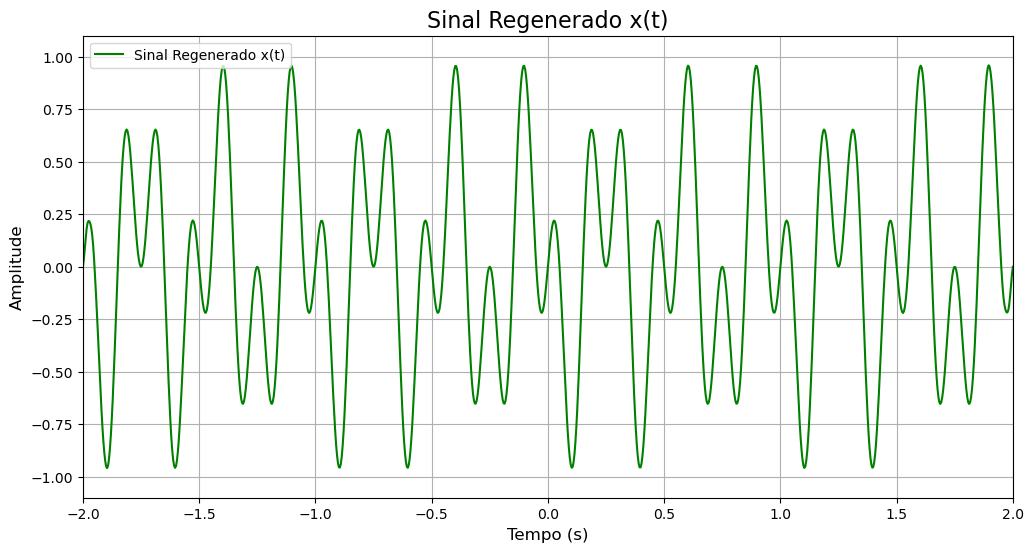

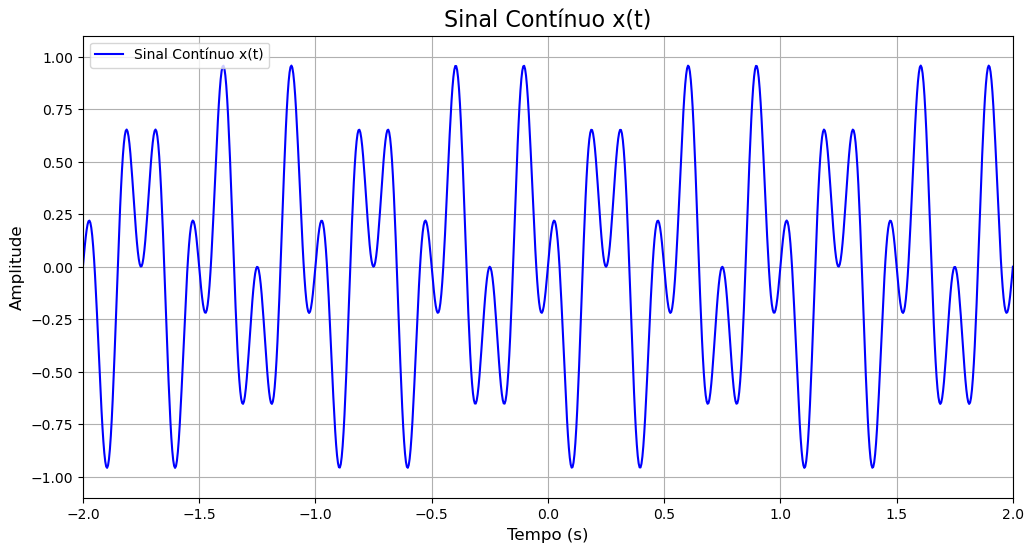

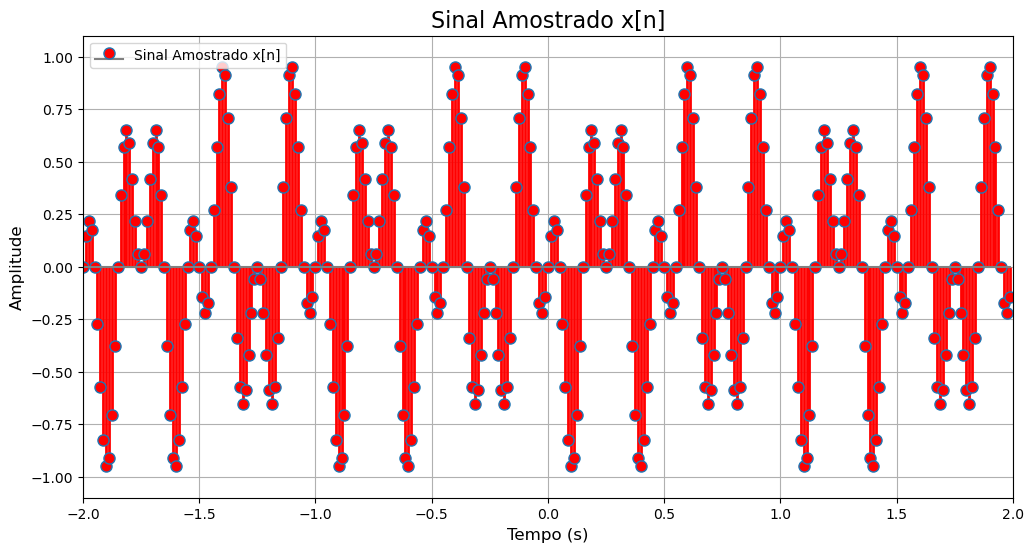

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# --- Parâmetros do Sinal com Frequências Ajustadas para Melhor Visualização ---
N = 1000  # numero de amostras
start = -2.0  # início do vetor t
end = 2.0  # fim do vetor t

# Vetor de tempo para o sinal contínuo x(t)
t = np.linspace(start, end, N)

A = 1  # amplitude do sinal
phi = 0  # fase do sinal


f1 = 2  # frequência do sinal 2 em Hz
f2 = 5  # frequência do sinal 5 em Hz

f_max = max(f1, f2)  # Frequência máxima do sinal

# Sinal x(t) 
x_t = A * np.sin(2 * np.pi * f1 * t + phi) * (A * np.cos(2 * np.pi * f2 * t + phi))

f_nyquist = 2 * f_max  # Frequência de Nyquist
f_s = (8)* f_nyquist   # Frequência de amostragem 
t_s = 1 / f_s         # Período de amostragem

# Vetor de tempo para o sinal amostrado x[n]
n = np.arange(start, end, t_s)

# Sinal amostrado x[n]
x_n = A * np.sin(2 * np.pi * f1 * n + phi) * (A * np.cos(2 * np.pi * f2 * n + phi))

def signal_regen(x_n,n_amostras,ts,t): #x_n= X(n), ts_0= t_s, x_n= n*ts, ts= t_s, t= t, n_amostras = n

    signal = np.zeros_like(t)  # Inicializa o sinal vetor com zeros

    # Calcula o sinc para cada amostra

    for i in range (len(x_n)):# percorre o vertor x_n para cada posição i do vetor

        x_n_i = x_n[i]  # Varre o vetor x_n para pegar o valor da i-ésima amostra
        ts_x_n = n_amostras[i]  # Para cada i , calcula a i-esima amostra do periodo de amostragem

        # X(i) e (i)*(Ts) são os valores do sinal amostrado e do tempo amostrado, respectivamente


        # Calcula o sinc para cada i-esima amostra e soma as sincs ponderadas
        signal += x_n_i * np.sinc((t - ts_x_n) / ts)
    return signal



Rx_t = signal_regen(x_n,n, t_s,t)  # Chama a função para regenerar o sinal contínuo a partir do sinal amostrado

# a função signal_regen recebe o sinal amostrado x_n, o vetor de tempo n, o período de amostragem t_s e o vetor de tempo t para gerar o sinal contínuo Rx_t

#==============================================================
plt.figure(figsize=(15, 8))

# --- Definindo a área de Zoom ---
# Vamos focar em 3 amostras a partir do índice 15 do seu vetor 'n'
indice_de_inicio_do_zoom = 15
numero_de_curvas = 3

# Ponto central para o zoom
tempo_central = n[indice_de_inicio_do_zoom + 1] 
largura_do_zoom = t_s * 5
zoom_start = tempo_central - largura_do_zoom / 2
zoom_end = tempo_central + largura_do_zoom / 2

# --- Vetor de tempo de ALTA RESOLUÇÃO (a solução para as curvas 'feias') ---
t_alta_resolucao = np.linspace(zoom_start, zoom_end, 2000)

# Cores para as 3 curvas
colors = ['blue', 'green', 'red']

# --- Loop para plotar as 3 sincs escolhidas ---
for i in range(numero_de_curvas):
    # Índice da amostra atual que vamos usar de 'x_n' e 'n'
    indice_atual = indice_de_inicio_do_zoom + i

    # Pegando os valores diretamente dos seus vetores 'x_n' e 'n'
    valor_da_amostra = x_n[indice_atual]
    tempo_da_amostra = n[indice_atual]
    
    if valor_da_amostra == 0:
        continue
        
    # Usando o t_alta_resolucao para o cálculo da curva suave
    sinc_individual = np.sign(valor_da_amostra) * np.sinc((t_alta_resolucao - tempo_da_amostra) / t_s)
    
    # Plotando com o t_alta_resolucao no eixo X
    plt.plot(t_alta_resolucao, sinc_individual, linestyle='-', linewidth=2.5, color=colors[i], label=f'Sinc em t={tempo_da_amostra:.2f}s')

# --- Configurações finais do gráfico ---
plt.title('Sincs Ponderadas', fontsize=18)
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Amplitude Normalizada', fontsize=12)
plt.xlim(zoom_start, zoom_end)
plt.ylim(-1.2, 1.2)
plt.legend(loc='lower left', fontsize='medium')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.axhline(0, color='black', linewidth=0.7)
# Adicionando linhas verticais nos tempos exatos das amostras
for i in range(numero_de_curvas):
    plt.axvline(n[indice_de_inicio_do_zoom + i], color=colors[i], linestyle=':', alpha=0.7)
plt.show()
#==============================================================


# --- Gráfico do Sinal Regenerado ---
plt.figure(figsize=(12, 6)) 
plt.plot(t, Rx_t, label='Sinal Regenerado x(t)', color='green')
plt.title('Sinal Regenerado x(t)', fontsize=16)
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.xlim(start, end)
plt.ylim(-A * 1.1, A * 1.1)
plt.legend()
plt.grid(True)
plt.show()  # Mostra o gráfico do sinal regenerado

# --- Gráfico de x(t) ---
plt.figure(figsize=(12, 6))
plt.plot(t, x_t, label='Sinal Contínuo x(t)', color='blue')
plt.title('Sinal Contínuo x(t)', fontsize=16)
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.xlim(start, end)
plt.ylim(-A * 1.1, A * 1.1)
plt.legend()
plt.grid(True)


# --- Gráfico de x[n] ---
plt.figure(figsize=(12, 6))
# Usando markerfmt e linefmt para customizar o gráfico de stem
markerline, stemlines, baseline = plt.stem(n, x_n, label='Sinal Amostrado x[n]', basefmt="gray")
plt.setp(markerline, 'markerfacecolor', 'red', 'markersize', 8)
plt.setp(stemlines, 'color', 'red', 'linewidth', 2)

plt.title('Sinal Amostrado x[n]', fontsize=16)
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.xlim(start, end)
plt.ylim(-A * 1.1, A * 1.1)
plt.legend()
plt.grid(True)


## Experimento 1.3

### Objetivo

O objetivo deste experimento é simular a digitalização de um sinal analógico composto, introduzir uma perturbação na forma de ruído aditivo e observar os efeitos dessa corrupção no domínio do tempo.

### Descrição do Sinal

O sinal de base para este experimento é um sinal contínuo no tempo, $x(t)$, composto pela soma de duas cossenoides com amplitudes e frequências distintas. A expressão matemática que define o sinal é:

$$x(t) = 5\cos(2\pi \cdot 5t) + 2\cos(2\pi \cdot 50t)$$

Este sinal possui dois componentes principais:
1.  Um componente de baixa frequência com amplitude **5.0** e frequência de **5 Hz**.
2.  Um componente de alta frequência com amplitude **2.0** e frequência de **50 Hz**.

### Parâmetros de Simulação

Para a simulação digital, foram adotados os seguintes parâmetros:

* **Frequência de Amostragem ($F_s$)**: O sinal contínuo $x(t)$ foi amostrado a uma taxa de **1000 amostras por segundo** (1000 Hz). Isso resulta em um período de amostragem $T_s = 1/F_s = 0.001$ segundos (1 ms).

* **Corrupção por Ruído**: Após a geração do sinal digital limpo, ele é corrompido por uma pequena quantidade de ruído para simular um cenário mais realista, como o de uma medição com interferência. O sinal ruidoso, $y(t)$, é o resultado da soma do sinal original com o ruído.

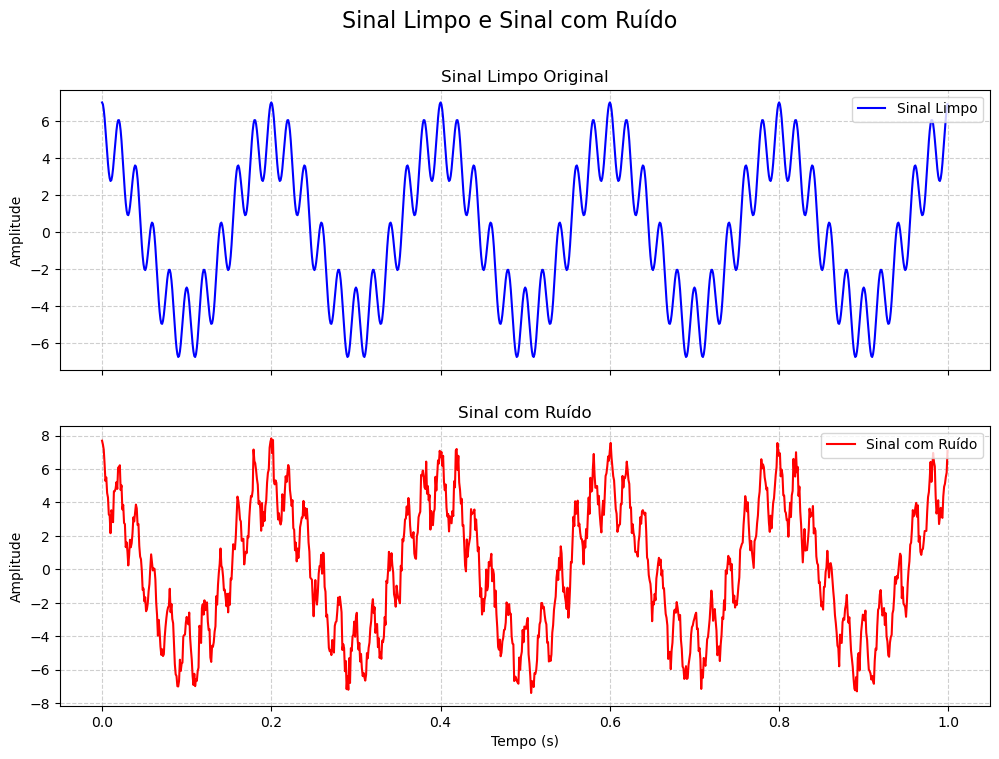

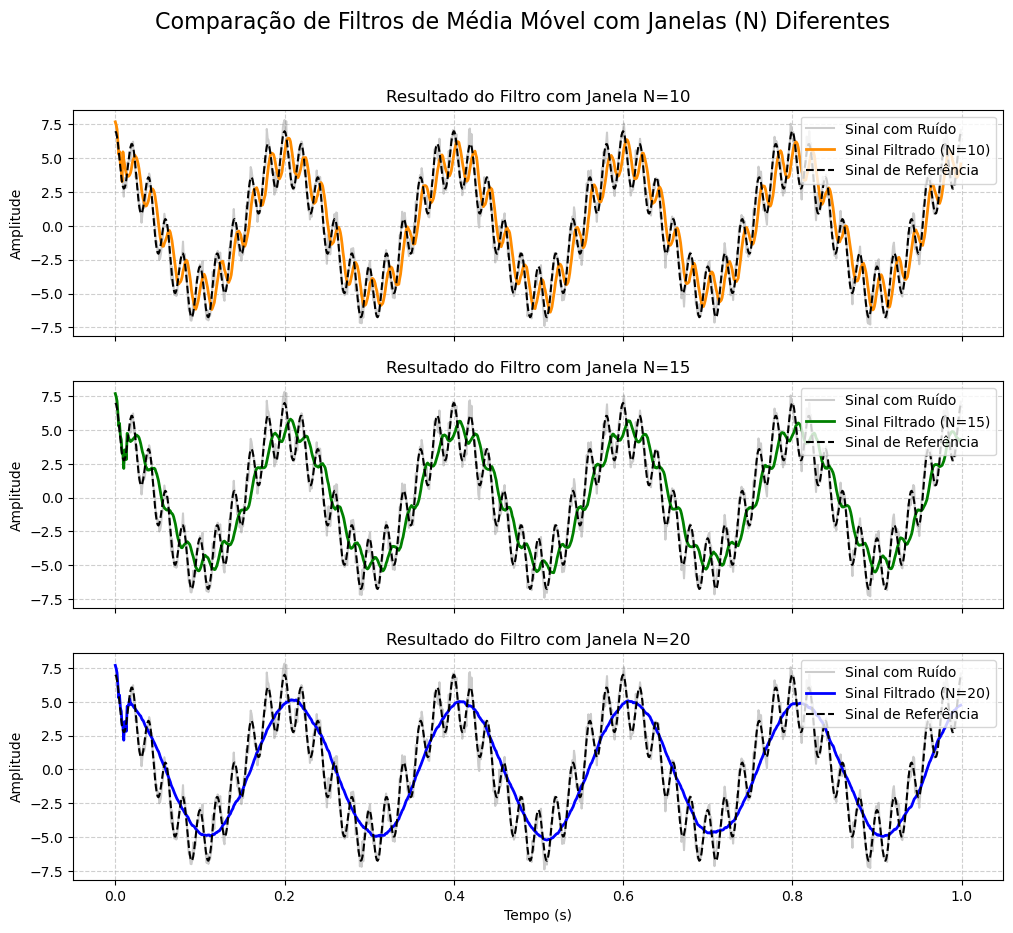

In [43]:
import numpy as np  
import matplotlib.pyplot as plt  
import scipy.signal as signal  

# --- 2. Definição dos Parâmetros dos Sinais ---

# Parâmetros para o primeiro sinal 
amplitude1 = 5.0
freq_1 = 5.0

# Parâmetros para o segundo sinal 
amplitude2 = 2.0
freq_2 = 50.0


Fs = 1000      # Frequência de amostragem (em Hz): 1000 amostras por segundo.
Ts = 1/Fs      # Período de amostragem: o intervalo de tempo entre cada amostra.
time_vector = np.arange(0, 1, Ts)  # Cria um vetor de tempo, de 0 até (quase) 1 segundo.

# --- 4. Geração dos Sinais e do Ruído ---

# Criação do primeiro sinal cosseno.
signal1 = amplitude1 * np.cos(2 * np.pi * freq_1 * time_vector)

# Criação do segundo sinal cosseno.
signal2 = amplitude2 * np.cos(2 * np.pi * freq_2 * time_vector)

# Geração de um ruído gaussiano (aleatório, com distribuição normal) com média 0 e desvio padrão 0.5.
noise = np.random.normal(0, 0.5, signal1.shape)

# Soma dos dois sinais para criar o sinal limpo composto de duas senoides
clear_signal = signal1 + signal2

# Adição do ruído ao sinal limpo 
noise_signal = clear_signal + noise


# Cria uma figura com 2 subplots para os sinais com ruido e sem ruido
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Sinal Limpo e Sinal com Ruído', fontsize=16)

# Plot no primeiro eixo (o de cima)
axs[0].plot(time_vector, clear_signal, color='blue', label='Sinal Limpo')
axs[0].set_title('Sinal Limpo Original')
axs[0].set_ylabel('Amplitude')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot no segundo eixo (o de baixo)
axs[1].plot(time_vector, noise_signal, color='red', label='Sinal com Ruído')
axs[1].set_title('Sinal com Ruído')
axs[1].set_ylabel('Amplitude')
axs[1].set_xlabel('Tempo (s)')
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.6)


# Define a função que aplica o filtro de média móvel, baseada na equação de diferença finita, demonstrada no livro
def reduce_noise(signal, N):
    new_signal = np.copy(signal)
    for n in range(N-1, len(signal)):
        new_signal[n] = np.mean(signal[n-N+1:n+1])
    return new_signal


# Aplica o filtro de média móvel com três tamanhos de janela diferentes. Para cada N.
N_20 = reduce_noise(noise_signal, 20)
N_15 = reduce_noise(noise_signal, 15)
N_10 = reduce_noise(noise_signal, 10)

# Cria uma nova figura com 3 subplots (empilhados), compartilhando os eixos X e Y.
# sharex e sharey garantem que a escala de tempo e amplitude seja a mesma em todos, para uma comparação justa.
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)
fig.suptitle('Comparação de Filtros de Média Móvel com Janelas (N) Diferentes', fontsize=16)

# --- Subplot 1: Filtro com N=10 ---
axs[0].set_title('Resultado do Filtro com Janela N=10')
# Plota o sinal ruidoso no fundo como contexto.
axs[0].plot(time_vector, noise_signal, color='gray', alpha=0.4, label='Sinal com Ruído')
# Plota o sinal filtrado.
axs[0].plot(time_vector, N_10, color='darkorange', linewidth=2, label='Sinal Filtrado (N=10)')
# Plota o sinal limpo como referência.
axs[0].plot(time_vector, clear_signal, 'k--', linewidth=1.5, label='Sinal de Referência')
axs[0].set_ylabel('Amplitude')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--', alpha=0.6)

# --- Subplot 2: Filtro com N=15 ---
axs[1].set_title('Resultado do Filtro com Janela N=15')
axs[1].plot(time_vector, noise_signal, color='gray', alpha=0.4, label='Sinal com Ruído')
axs[1].plot(time_vector, N_15, color='green', linewidth=2, label='Sinal Filtrado (N=15)')
axs[1].plot(time_vector, clear_signal, 'k--', linewidth=1.5, label='Sinal de Referência')
axs[1].set_ylabel('Amplitude')
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.6)

# --- Subplot 3: Filtro com N=20 ---
axs[2].set_title('Resultado do Filtro com Janela N=20')
axs[2].plot(time_vector, noise_signal, color='gray', alpha=0.4, label='Sinal com Ruído')
axs[2].plot(time_vector, N_20, color='blue', linewidth=2, label='Sinal Filtrado (N=20)')
axs[2].plot(time_vector, clear_signal, 'k--', linewidth=1.5, label='Sinal de Referência')
axs[2].set_ylabel('Amplitude')
axs[2].set_xlabel('Tempo (s)') # Adiciona o rótulo do eixo X apenas no último gráfico.
axs[2].legend(loc='upper right')
axs[2].grid(True, linestyle='--', alpha=0.6)

# Exibe todas as figuras geradas.
plt.show()